# Rebuild CSI-Bench splits (window-level leakage fix)

Interactive companion to `rebuild_splits.py`. Use this notebook to:
1. Inspect the `session` gap distribution and pick `GAP_THRESH`
2. Run the full buffered group-split pipeline
3. Confirm the crossing check reads ~0% and label coverage is intact

Run this once for `HumanIdentification`, then again for `HumanActivityRecognition`
(re-check the gap distribution independently for each task -- `GAP_THRESH` may differ).

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import sys
sys.path.insert(0, "/home/zhuzih19/csi-project/csi-fall-detection")  # adjust if rebuild_splits.py lives elsewhere

import numpy as np
import matplotlib.pyplot as plt

from rebuild_splits import (
    GROUP_COLS, ORDER_COL, ID_COL,
    load_metadata, compute_gap_stats, build_trial_blocks,
    buffered_group_split, crossing_check, coverage_check,
    write_split_json, main,
)

In [5]:
# -- Set this per task --
TASK_DIR = "/home/zhuzih19/data/csi-bench-dataset/Multitask/HumanActivityRecognition"
META_PATH = f"{TASK_DIR}/metadata/sample_metadata.csv"
LABEL_COL = "user"  # HID identifies users; use the appropriate label column for HAR

meta = load_metadata(META_PATH)
print("rows:", len(meta))
meta.head()

rows: 55684


,id,file_path,subject,user,activity,distance,num_sub,environment,device,session,is_multi_subject,label
0,Human_U01_jumping_E01_AmazonPlug_56_16000,../../sub_Human_h5/user_U01/act_jumping/env_E0...,Human,U01,jumping,1.5,56,E01,AmazonPlug,16000,False,jumping
1,Human_U01_jumping_E01_AmazonPlug_56_16001,../../sub_Human_h5/user_U01/act_jumping/env_E0...,Human,U01,jumping,1.5,56,E01,AmazonPlug,16001,False,jumping
2,Human_U01_jumping_E01_AmazonPlug_56_16002,../../sub_Human_h5/user_U01/act_jumping/env_E0...,Human,U01,jumping,1.5,56,E01,AmazonPlug,16002,False,jumping
3,Human_U01_jumping_E01_AmazonPlug_56_16003,../../sub_Human_h5/user_U01/act_jumping/env_E0...,Human,U01,jumping,1.5,56,E01,AmazonPlug,16003,False,jumping
4,Human_U01_jumping_E01_AmazonPlug_56_16004,../../sub_Human_h5/user_U01/act_jumping/env_E0...,Human,U01,jumping,1.5,56,E01,AmazonPlug,16004,False,jumping


## Step 1 -- Inspect gaps to choose `GAP_THRESH`

Look for the point where the distribution jumps from a small/dense cluster
(still the same recording trial) to large gaps (a new trial started).

Gap stats: {'n_gaps': 55306, 'fraction_gap_eq_1': 0.9752829711062091, 'percentiles_50_75_90_95_99': [1.0, 1.0, 1.0, 1.0, 982.0]}


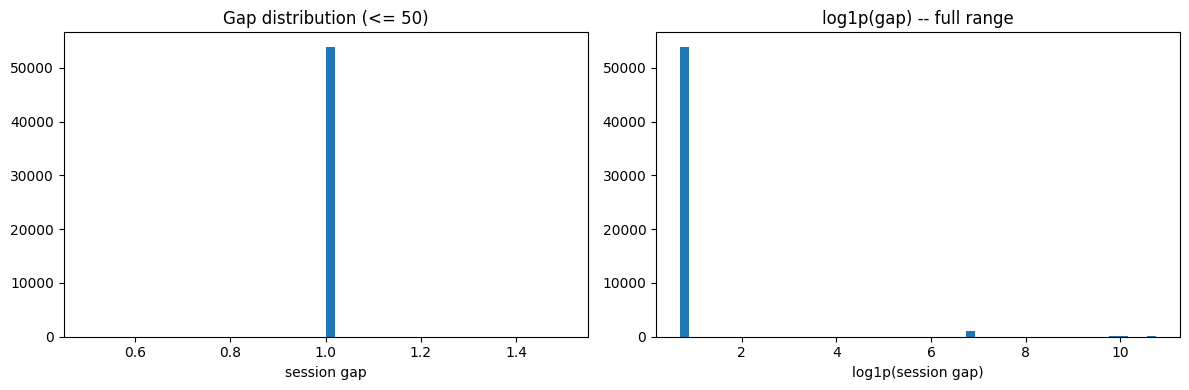

In [6]:
gaps, stats = compute_gap_stats(meta, GROUP_COLS, ORDER_COL)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(gaps[gaps <= 50], bins=50)
axes[0].set_title("Gap distribution (<= 50)")
axes[0].set_xlabel("session gap")

axes[1].hist(np.log1p(gaps), bins=50)
axes[1].set_title("log1p(gap) -- full range")
axes[1].set_xlabel("log1p(session gap)")
plt.tight_layout()
plt.show()

In [7]:
# -- Set based on the plot/percentiles above --
GAP_THRESH = 5
BUFFER_BLOCKS = 1

## Step 2 -- Sanity check trial-block segmentation before committing

num trial blocks: 1745
count    1745.000000
mean       31.910602
std        13.301981
min         7.000000
25%        19.000000
50%        36.000000
75%        38.000000
max        80.000000
dtype: float64


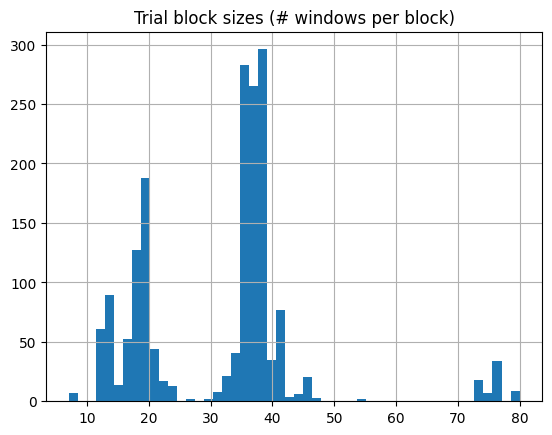

In [8]:
import importlib, rebuild_splits
importlib.reload(rebuild_splits)
from rebuild_splits import build_trial_blocks

meta_blocks = build_trial_blocks(meta.copy(), GROUP_COLS, GAP_THRESH, ORDER_COL)
block_sizes = meta_blocks.groupby("trial_key").size()
print(block_sizes.describe())
block_sizes.hist(bins=50)
plt.title("Trial block sizes (# windows per block)")
plt.show()

## Step 3 -- Run the full pipeline (final 70/15/15 + nested 85/15 HP split)

This backs up the original split files, builds the buffered group split,
runs crossing/coverage checks, and writes the new split JSONs -- all via
`rebuild_splits.main()`, so this notebook and the command-line script stay
in sync.

In [9]:
meta_final, train_pool = main(
    TASK_DIR,
    gap_thresh=GAP_THRESH,
    buffer_blocks=BUFFER_BLOCKS,
    label_col=LABEL_COL,
)

Backed up original split files to /home/zhuzih19/data/csi-bench-dataset/Multitask/HumanActivityRecognition/splits/backup_original
Gap stats: {'n_gaps': 55306, 'fraction_gap_eq_1': 0.9752829711062091, 'percentiles_50_75_90_95_99': [1.0, 1.0, 1.0, 1.0, 982.0]}
group_level_split: 378 groups, 55684 windows
  train: 38977 windows (70.0%)
  val: 8354 windows (15.0%)
  test: 8353 windows (15.0%)

--- Final split value counts ---
split
train    38977
val       8354
test      8353
Name: count, dtype: int64

--- Crossing check (final split) ---
adjacent pairs: 53939, crossing split boundary: 0 (0.00%)

--- Coverage check (final split) ---
user    U01   U02   U03   U04   U05   U06   U22
split                                          
test   1502  1097   583   591  1782   670  2128
train  4926  8948  2667  4308  9422  4987  3719
val     724  2064   311  1388  2534   618   715
group_level_split: 268 groups, 38977 windows
  train_hp: 33131 windows (85.0%)
  val_hp: 5846 windows (15.0%)

--- HP split

## Step 4 -- Confirm the fix

Crossing check should now read ~0%. If it doesn't, increase `BUFFER_BLOCKS`
above and rerun from Step 3.

In [10]:
print("Final split sizes:")
print(meta_final['split'].value_counts())
print()
print("HP split sizes (within train pool):")
print(train_pool['split'].value_counts())

Final split sizes:
split
train    38977
val       8354
test      8353
Name: count, dtype: int64

HP split sizes (within train pool):
split
train_hp    33131
val_hp       5846
Name: count, dtype: int64


## Step 5 -- Repeat for HAR

Change `TASK_DIR` to `.../Multitask/HumanActivityRecognition`, re-run Step 1
to re-check the gap distribution independently (it may need a different
`GAP_THRESH`), set `LABEL_COL` to HAR's activity label column, then re-run
Steps 2-4.